In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, BaggingClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import matthews_corrcoef
from sklearn.metrics import cohen_kappa_score
!pip install lightgbm
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier



# Install CatBoost
!pip install catboost

from catboost import CatBoostClassifier


from google.colab import files
uploaded = files.upload()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.7 MB/s eta 0:00:00


Saving bank-additional-full.csv to bank-additional-full.csv


In [2]:
df = pd.read_csv('/content/bank-additional-full.csv', sep=';')

In [3]:
# 3. Drop Leakage Feature
df.drop('duration', axis=1, inplace=True)

In [4]:
# 4. Handle "unknown" Values
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].replace('unknown', df[col].mode()[0])

In [5]:
# 5. Encode Target
df['y'] = df['y'].map({'no': 0, 'yes': 1})
# 6. One-Hot Encoding
df = pd.get_dummies(df, drop_first=True)
X_shuffled = df.drop('y', axis=1)
y_shuffled = df['y']

In [6]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from scipy.stats import uniform

# Split
X_train, X_test, y_train, y_test = train_test_split(X_shuffled, y_shuffled, test_size=0.2, random_state=42)


In [7]:
# Model
from sklearn.ensemble import RandomForestClassifier
model2 = RandomForestClassifier()

# Search space
param_dist2 = {
         "n_estimators":[100,200,300],
    "max_depth":[10,20,None],
    "min_samples_split":[2,5],
    "min_samples_leaf":[1,2]
}

In [8]:
# RandomForestClassifier

random_search = RandomizedSearchCV(model2, param_distributions=param_dist2, n_iter=5,
                                   cv=10, scoring="accuracy", random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

best_model_LR = random_search.best_estimator_
print("Best parameters:", random_search.best_params_)
print("Best CV accuracy: {:.4f}".format(random_search.best_score_))
print("Test accuracy: {:.4f}".format(best_model_LR.score(X_test, y_test)))

Best parameters: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': None}
Best CV accuracy: 0.9003
Test accuracy: 0.8967



  SHAP EXPLANATION 


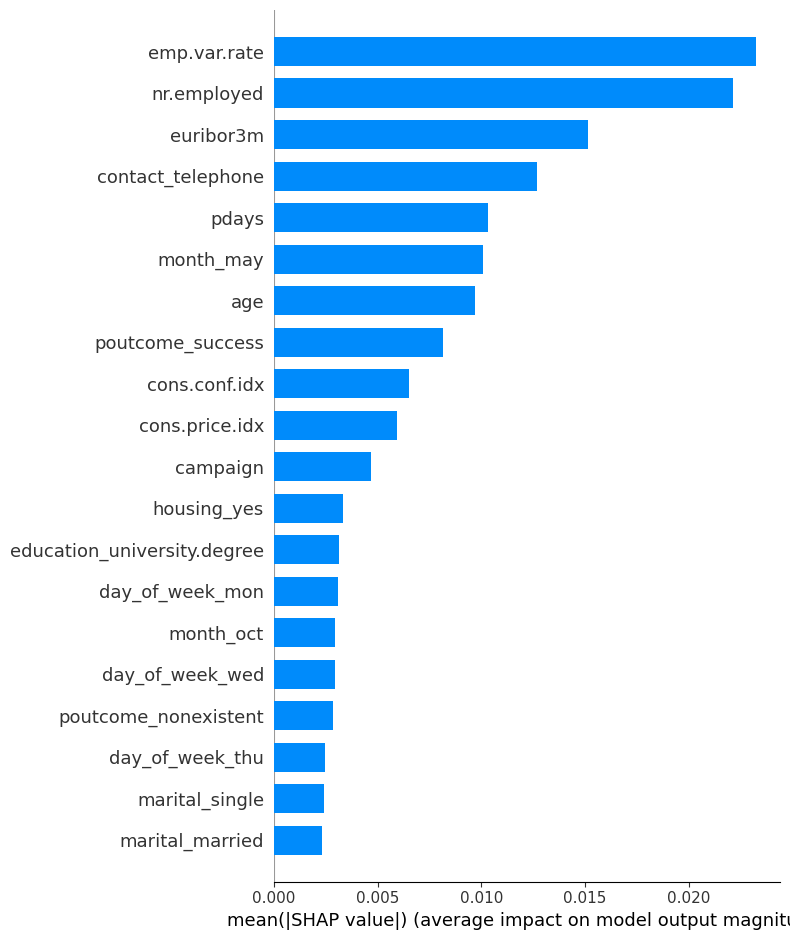

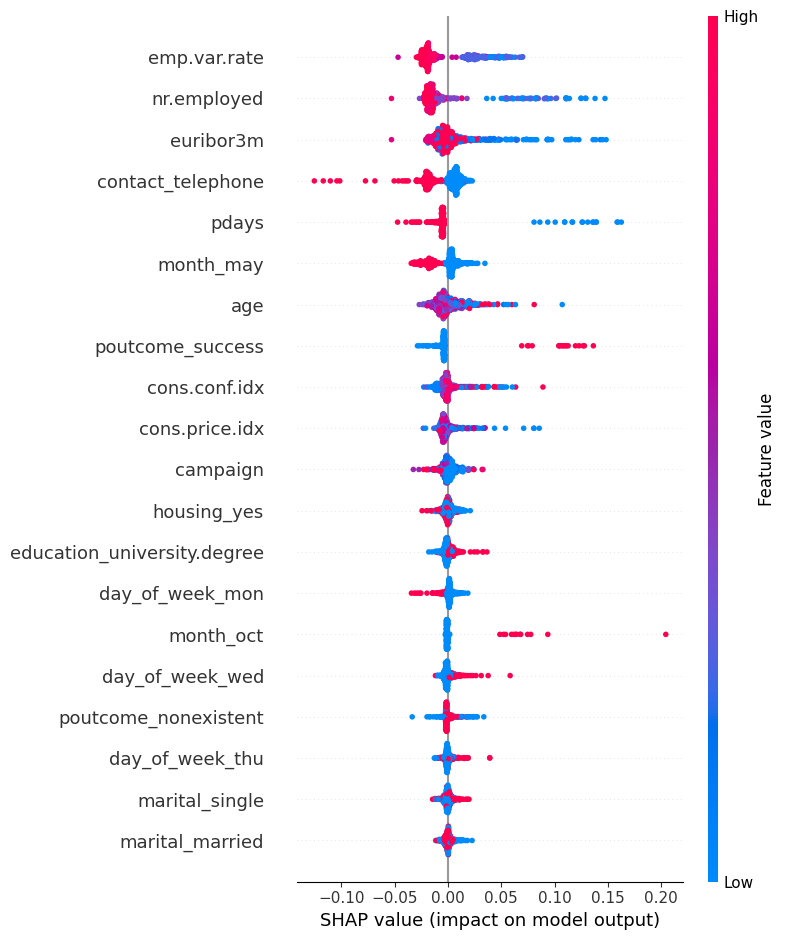

<Figure size 640x480 with 0 Axes>

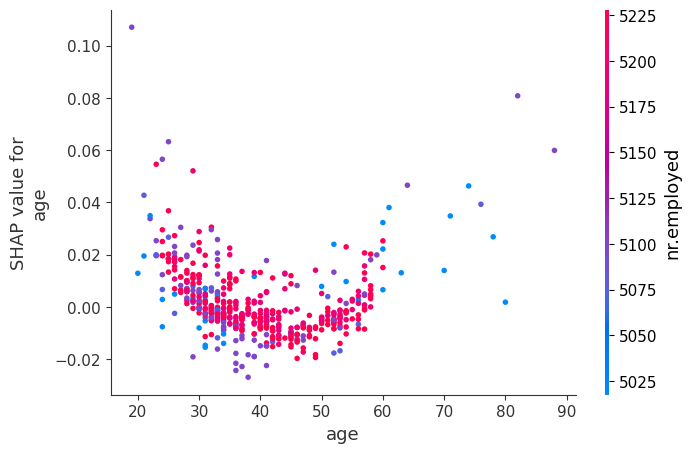

In [10]:
import shap
import matplotlib.pyplot as plt

print("\n  SHAP EXPLANATION ")
shap.initjs()
X_sample = X_train.sample(500,random_state=42)
# Create TreeExplainer
explainer = shap.TreeExplainer(best_model_LR)

# Compute SHAP values
shap_values = explainer.shap_values(X_sample)

# For binary classification → explain class 1
shap_vals = shap_values[:,:,1]

# Global Feature Importance
plt.figure()
shap.summary_plot(shap_vals, X_sample,plot_type="bar")

#  Detailed Summary Plot
plt.figure()
shap.summary_plot(shap_vals, X_sample)

#  Dependence Plot
plt.figure()
shap.dependence_plot(
    X_sample.columns[0],
    shap_vals,
    X_sample
)

#  Force Plot (Single Prediction)


shap.force_plot(
    explainer.expected_value[1],
    shap_vals[0],
    X_sample.iloc[0]
)

In [11]:
# SCALING (IMPORTANT FOR LIME)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:


# create model
model2 = RandomForestClassifier(n_estimators=100, random_state=42)

# train model
model2.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [19]:
!pip install lime
from lime.lime_tabular import LimeTabularExplainer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=245c117a479e5ce106a02fe52f947f960bef4d4d841025abb785ed3d5f072c54
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [20]:


print("\n--- LIME EXPLANATION ---")

# FIX HERE
feature_names = X_train.columns.tolist()   # or manually define

lime_explainer = LimeTabularExplainer(
    training_data=X_train_scaled,
    feature_names=feature_names,
    class_names=['Malignant', 'Benign'],
    mode='classification'
)

lime_exp = lime_explainer.explain_instance(
    X_test_scaled[0],
    model2.predict_proba
)

lime_exp.show_in_notebook(show_table=True)


--- LIME EXPLANATION ---


In [22]:
# Model
from sklearn.svm import LinearSVC
model4 = LinearSVC()



from sklearn.svm import LinearSVC

model4 = LinearSVC()

param_dist4 = {
    "C": [0.01, 0.1, 1, 10],
    "loss": ["hinge", "squared_hinge"],
    "max_iter": [1000, 2000]
}

In [23]:
# LinearSVC

random_search = RandomizedSearchCV(model4, param_distributions=param_dist4, n_iter=10,
                                   cv=10, scoring="accuracy", random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

best_model_LR = random_search.best_estimator_
print("Best parameters:", random_search.best_params_)
print("Best CV accuracy: {:.4f}".format(random_search.best_score_))
print("Test accuracy: {:.4f}".format(best_model_LR.score(X_test, y_test)))

Best parameters: {'max_iter': 1000, 'loss': 'squared_hinge', 'C': 10}
Best CV accuracy: 0.9004
Test accuracy: 0.8972



  SHAP EXPLANATION 


  0%|          | 0/100 [00:00<?, ?it/s]

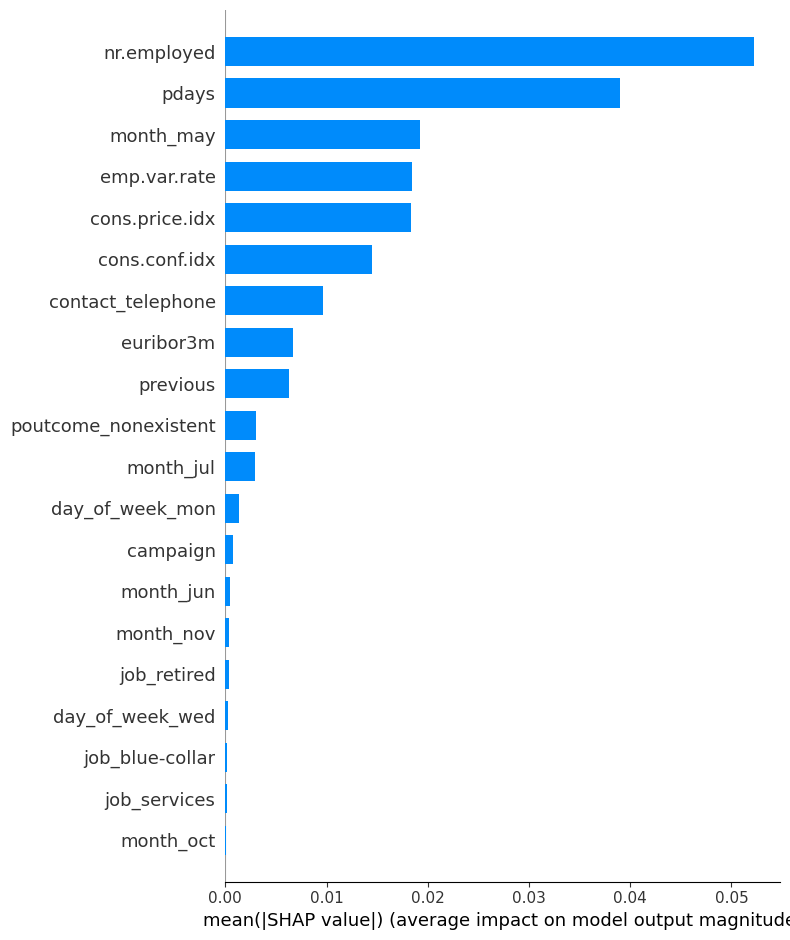

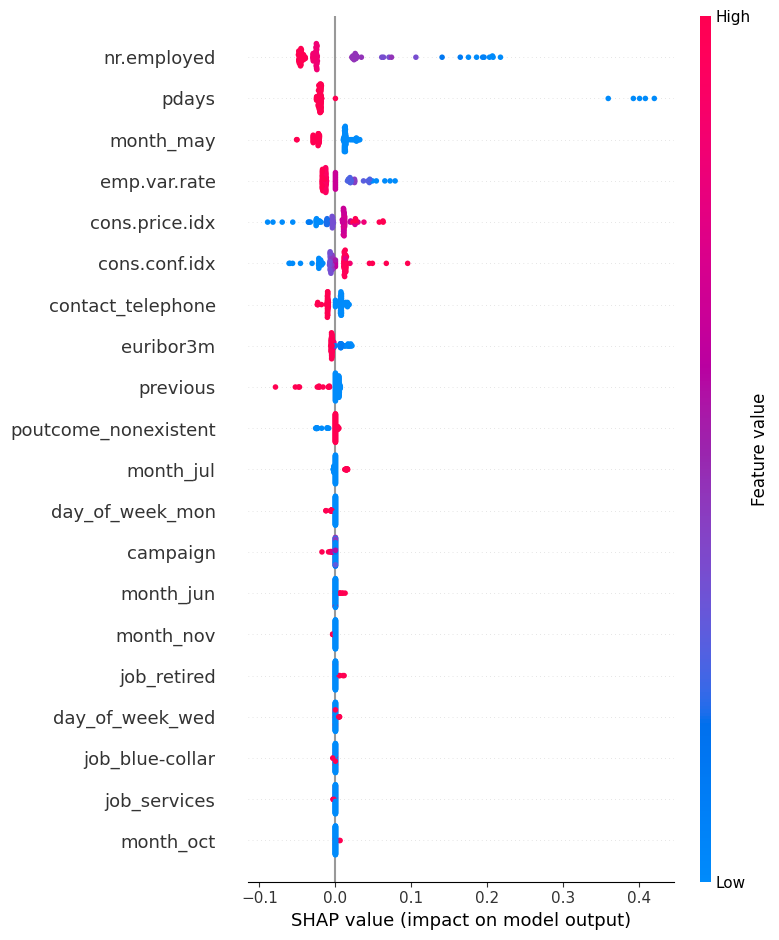

<Figure size 640x480 with 0 Axes>

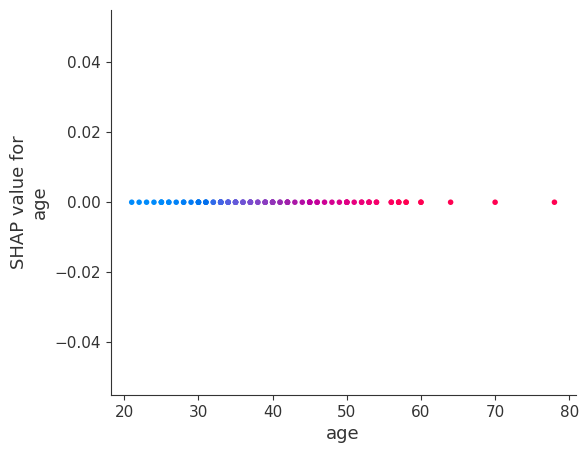

In [24]:
import shap
import matplotlib.pyplot as plt
from sklearn.calibration import CalibratedClassifierCV
print("\n  SHAP EXPLANATION ")
svm = CalibratedClassifierCV(best_model_LR)
svm.fit(X_train,y_train)
X_sample = X_train.sample(100,random_state=42)
# Create KernelExplainer
explainer = shap.KernelExplainer(svm.predict_proba,X_sample)

# Compute SHAP values
shap_values = explainer.shap_values(X_sample)

# For binary classification → explain class 1
shap_vals = shap_values[:,:,1]

# Global Feature Importance
plt.figure()
shap.summary_plot(shap_vals, X_sample, plot_type="bar")

#  Detailed Summary Plot
plt.figure()
shap.summary_plot(shap_vals, X_sample)

#  Dependence Plot
plt.figure()
shap.dependence_plot(
    X_sample.columns[0],
    shap_vals,
    X_sample
)

#  Force Plot (Single Prediction)


shap.force_plot(
    explainer.expected_value[1],
    shap_vals[0],
    X_sample.iloc[0]
)

In [25]:
from lime.lime_tabular import LimeTabularExplainer
import numpy as np

print("\n--- LIME EXPLANATION (LinearSVC) ---")

# Feature names (VERY IMPORTANT)
feature_names = X_train.columns.tolist()

# Create explainer
lime_explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=feature_names,
    class_names=['Malignant', 'Benign'],
    mode='classification'
)

# Custom prediction function (since LinearSVC has no predict_proba)
def predict_fn(x):
    scores = best_model_LR.decision_function(x)

    # Convert to probability-like values using sigmoid
    probs = 1 / (1 + np.exp(-scores))

    # Convert to 2D (needed for LIME)
    return np.vstack([1 - probs, probs]).T

# Pick one test instance
i = 0

lime_exp = lime_explainer.explain_instance(
    X_test.iloc[i].values,
    predict_fn,
    num_features=10
)

# Show explanation
lime_exp.show_in_notebook(show_table=True)


--- LIME EXPLANATION (LinearSVC) ---


In [26]:
# Model

from xgboost import XGBClassifier

model5 =  XGBClassifier(use_label_encoder=False, eval_metric='logloss')

param_dist5 = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.1],
            "max_depth": [3, 6]
}

In [27]:
# XGBoost

random_search = RandomizedSearchCV(model5, param_distributions=param_dist5, n_iter=100,
                                   cv=20, scoring="accuracy", random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

best_model_LR = random_search.best_estimator_
print("Best parameters:", random_search.best_params_)
print("Best CV accuracy: {:.4f}".format(random_search.best_score_))
print("Test accuracy: {:.4f}".format(best_model_LR.score(X_test, y_test)))

Best parameters: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1}
Best CV accuracy: 0.9022
Test accuracy: 0.8973



SHAP EXPLANATION 


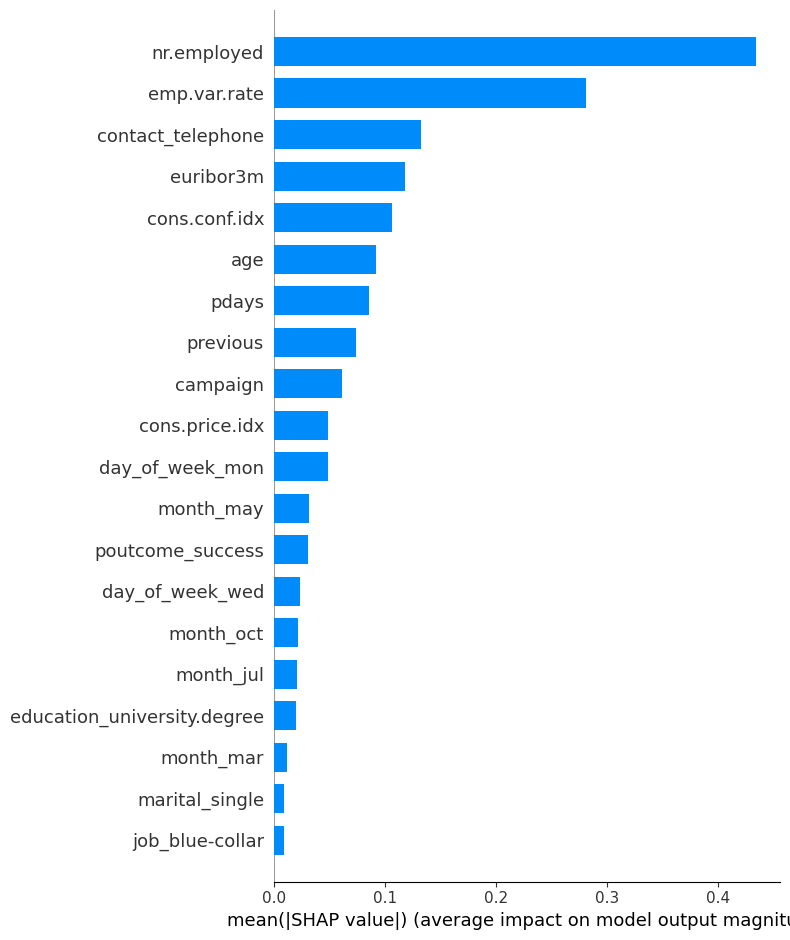

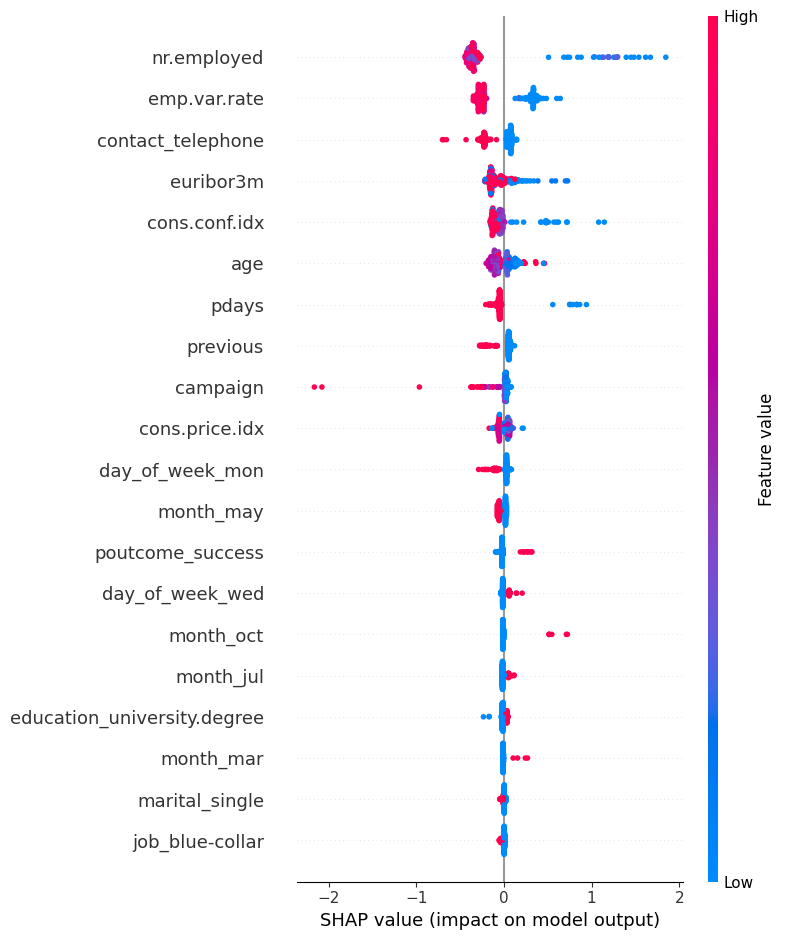

<Figure size 640x480 with 0 Axes>

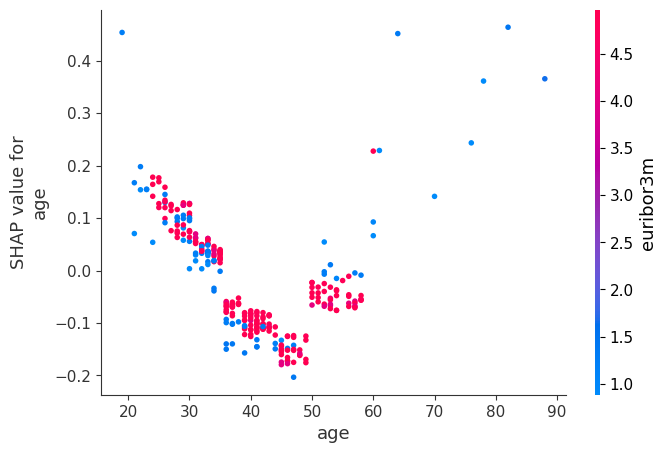

In [28]:
import shap
import numpy as np
import matplotlib.pyplot as plt

print("\nSHAP EXPLANATION ")

#  take small sample (SHAP is slow on full data)
X_sample = X_train.sample(300, random_state=42)

#  create explainer (new universal method)
explainer = shap.Explainer(best_model_LR)

#  generate SHAP values
shap_values = explainer(X_sample)

#  convert to correct matrix (binary classification → class 1)
if len(shap_values.values.shape)==3:
    shap_vals = shap_values.values[:,:, 1]
else:
    shap_vals = shap_values.values
#  Global Feature Importance (Bar)
plt.figure()
shap.summary_plot(shap_vals, X_sample, plot_type="bar")

#  Detailed Beeswarm Summary
plt.figure()
shap.summary_plot(shap_vals, X_sample)

#  Dependence Plot
plt.figure()
shap.dependence_plot(
    X_sample.columns[0],
    shap_vals,
    X_sample
)

#  Force Plot (Single Prediction)
shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_vals[0],
    X_sample.iloc[0]
)

In [29]:
import numpy as np
from lime.lime_tabular import LimeTabularExplainer

# Create explainer
explainer = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns,
    class_names=['Class 0', 'Class 1'],  # change if needed
    mode='classification'
)

# Pick one test instance
i = 0  # you can change index

# Explain prediction
exp = explainer.explain_instance(
    data_row=X_test.iloc[i],
    predict_fn=best_model_LR.predict_proba
)

# Show explanation
exp.show_in_notebook(show_table=True)

# OR print in console
print(exp.as_list())

[('month_oct <= 0.00', -0.19102544641041844), ('nr.employed <= 5099.10', 0.17435120471456506), ('emp.var.rate <= -1.80', 0.07509764885192474), ('contact_telephone <= 0.00', 0.050120260718541726), ('poutcome_success <= 0.00', -0.03080265648974184), ('month_mar <= 0.00', -0.02670830495110515), ('previous > 0.00', -0.023867275422173526), ('month_jul <= 0.00', -0.020685731246479676), ('day_of_week_mon > 0.00', -0.01856031016047351), ('cons.conf.idx <= -42.70', 0.016574647634208284)]


In [30]:
# Model

from xgboost import XGBClassifier

model5 =  XGBClassifier(use_label_encoder=False, eval_metric='logloss')

param_dist5 = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.1],
            "max_depth": [3, 6]
}